In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM

# Load dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Define columns
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels
data[text_column] = data[text_column].fillna("missing")

# TF-IDF Vectorization
max_features = 5000  # Maximum number of features in TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english')
X = tfidf_vectorizer.fit_transform(data[text_column])

# Dimensionality Reduction using SVD
svd_components = 300  # Reduce dimensions to 300
svd = TruncatedSVD(n_components=svd_components, random_state=42)
X_reduced = svd.fit_transform(X)

# Extract target values
y = data[target_column].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

# Build BiLSTM Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(svd_components,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("Training BiLSTM Model...")
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"BiLSTM Test Accuracy: {accuracy * 100:.2f}%")

# Save model
model_path = r"C:\Users\PC\Downloads\BiLSTM_TFIDF_model.h5"
model.save(model_path)
print(f"Trained BiLSTM model saved to {model_path}")

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Training BiLSTM Model...
Epoch 1/10
4641/4641 [==============================] - 46s 9ms/step - loss: 0.2398 - accuracy: 0.9084 - val_loss: 0.2140 - val_accuracy: 0.9174
Epoch 2/10
4641/4641 [==============================] - 34s 7ms/step - loss: 0.2103 - accuracy: 0.9201 - val_loss: 0.2052 - val_accuracy: 0.9209
Epoch 3/10
4641/4641 [==============================] - 33s 7ms/step - loss: 0.1969 - accuracy: 0.9247 - val_loss: 0.2011 - val_accuracy: 0.9226
Epoch 4/10
4641/4641 [==============================] - 33s 7ms/step - loss: 0.1882 - accuracy: 0.9284 - val_loss: 0.1999 - val_accuracy: 0.9229
Epoch 5/10
4641/4641 [==============================] - 34s 7ms/step - loss: 0.1805 - accuracy: 0.9311 - val_loss: 0.2020 - val_accuracy: 0.9238
Epoch 6/10
4641/4641 [==============================] - 33s 7ms/step - loss: 0.1744 - accuracy: 0.9330 - val_loss: 0.1992 - val_accuracy: 0.9247
Epoch 7/10
4641/4641 [==============================] - 34s 7ms/step - loss: 0.1703 - accuracy: 0.9347 - 

C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Trained BiLSTM model saved to C:\Users\PC\Downloads\BiLSTM_TFIDF_model.h5
1451/1451 [==============================] - 6s 4ms/step
Accuracy: 92.44%
Precision: 93.59%
Recall: 91.09%
F1 Score: 92.33%
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93     23238
           1       0.94      0.91      0.92     23171

    accuracy                           0.92     46409
   macro avg       0.92      0.92      0.92     46409
weighted avg       0.92      0.92      0.92     46409



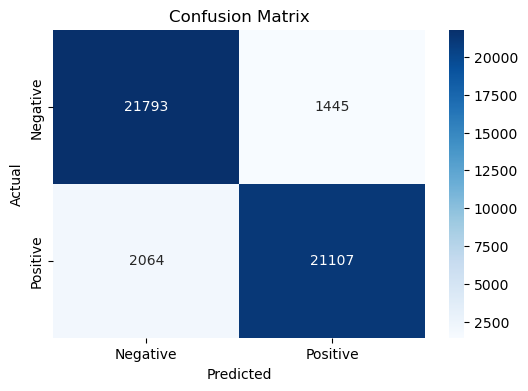

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are already defined
y_test = np.array(y_test)  # Ensure correct format
y_pred = np.array(y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


1451/1451 [==============================] - 6s 4ms/step


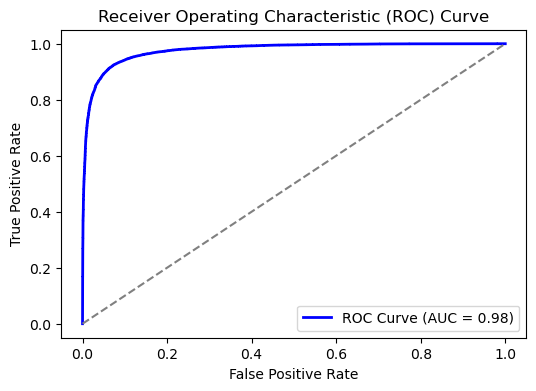

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming y_test and model are already defined
y_test = np.array(y_test)  # Ensure correct format
y_pred_proba = model.predict(X_test)  # Get probability predictions

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Mean Absolute Error (MAE): 0.1038
Mean Squared Error (MSE): 0.0570
Root Mean Squared Error (RMSE): 0.2387


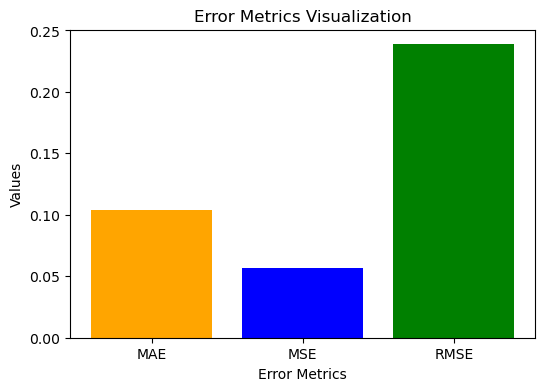

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming y_test and y_pred_proba are already defined
y_test = np.array(y_test)  # Ensure correct format
y_pred_proba = np.array(y_pred_proba)  # Ensure correct format

# Error Metrics
mae = mean_absolute_error(y_test, y_pred_proba)
mse = mean_squared_error(y_test, y_pred_proba)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Visualization
metrics = ['MAE', 'MSE', 'RMSE']
values = [mae, mse, rmse]

plt.figure(figsize=(6, 4))
plt.bar(metrics, values, color=['orange', 'blue', 'green'])
plt.xlabel('Error Metrics')
plt.ylabel('Values')
plt.title('Error Metrics Visualization')
plt.show()


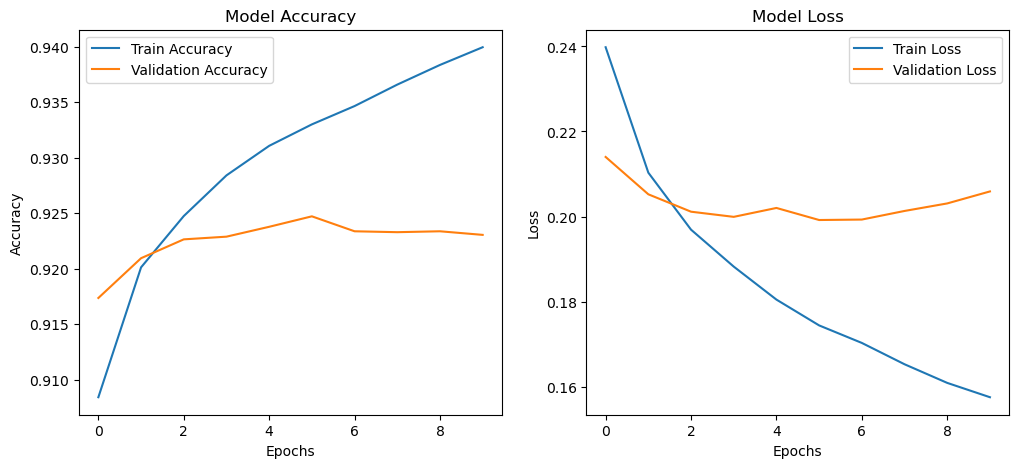

In [7]:
import matplotlib.pyplot as plt

# Accuracy and Loss Curves
plt.figure(figsize=(12, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()